In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots as sp
import sys, os

# General path for the project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
print("Project root:", project_root)

sys.path.append(project_root)

# Reading data from .npy files
data_without_radiative = np.load(f"{project_root}/results/data/muon_decay_samples_no_radiative_100000000_events.npy")
data_with_radiative = np.load(f"{project_root}/results/data/muon_decay_samples_radiative_100000000_events.npy")

Project root: /home/estiven/Proyectos/monte-carlo-particle-decay


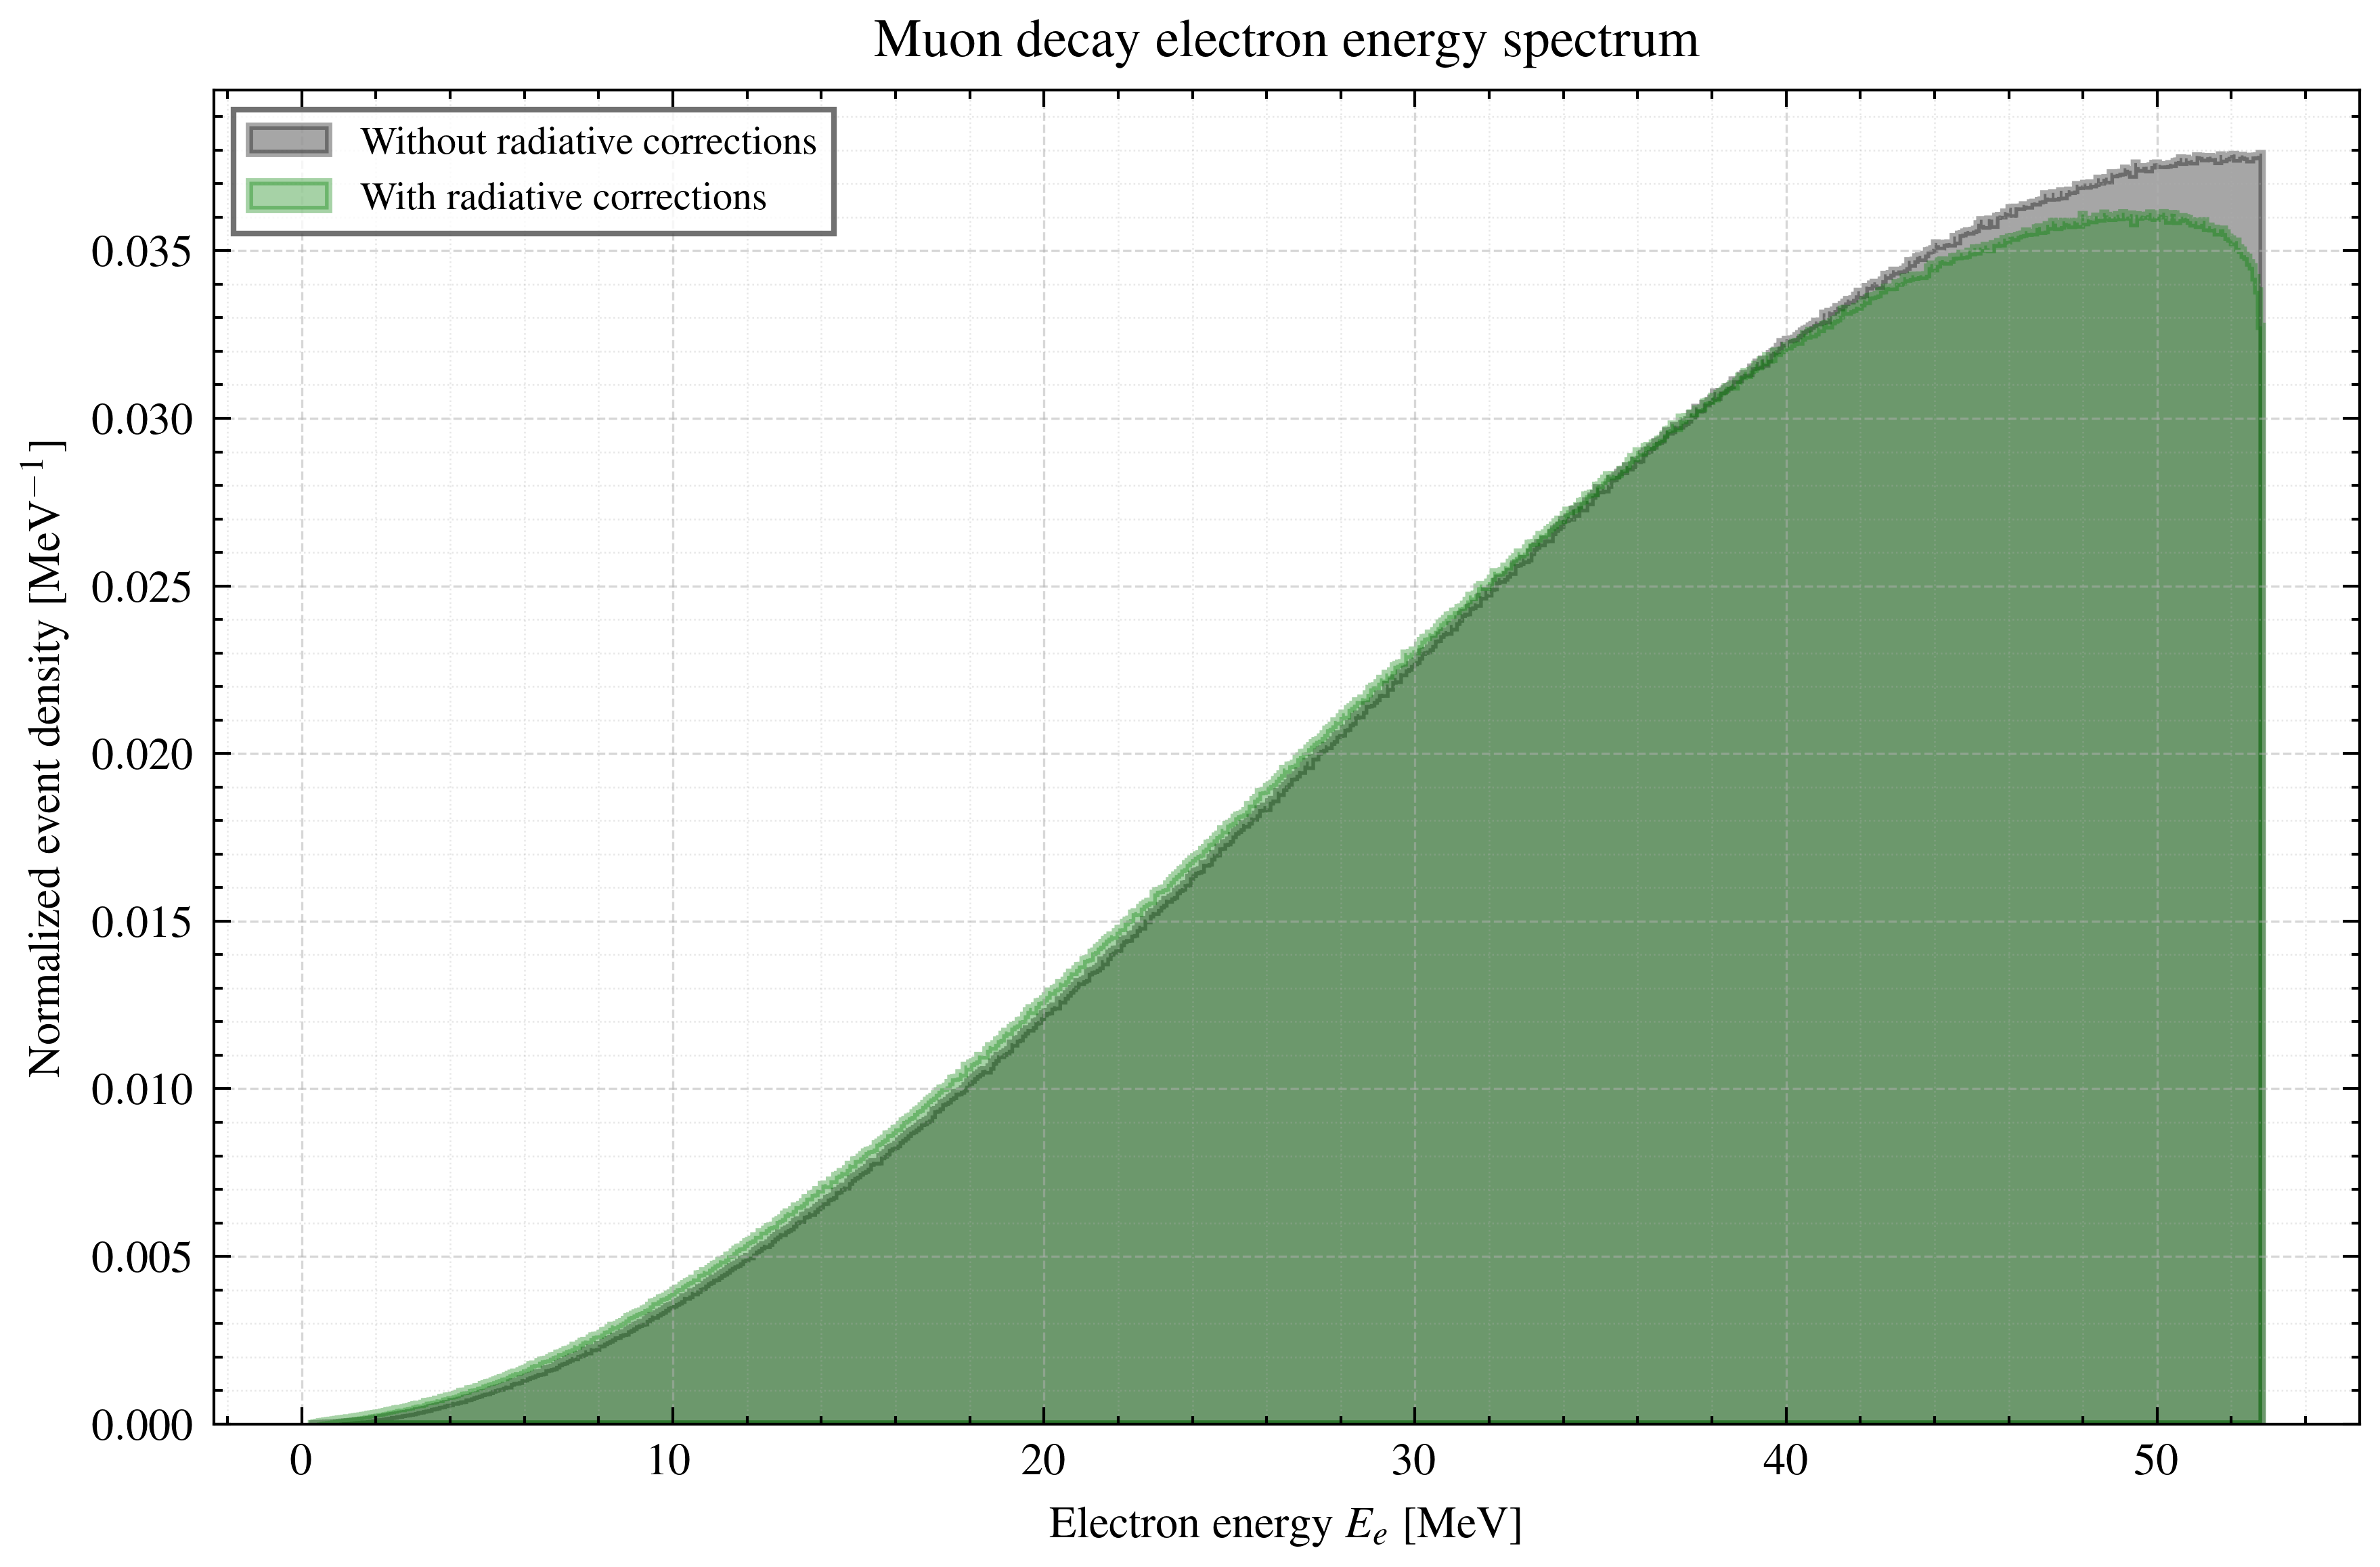

Summary statistics
Without radiative corrections:
  Peak density : 3.789794e-02 MeV^-1  at E_e = 52.7928 MeV
  Max E_e (endpoint observed): 52.8287 MeV

With radiative corrections:
  Peak density : 3.613309e-02 MeV^-1  at E_e = 50.1748 MeV
  Max E_e (endpoint observed): 52.8287 MeV

Difference in peak position: 2.6180 MeV
Difference in peak density : 1.764851e-03 MeV^-1


In [11]:
import matplotlib.pyplot as plt

plt.style.use(['science', 'ieee'])

fig, ax = plt.subplots(figsize=(6, 4))

# Histogramas superpuestos
counts_without, bins_without, _ = ax.hist(
    data_without_radiative[1],
    bins='fd',
    density=True,
    histtype='stepfilled',
    alpha=0.35,
    linewidth=1.3,
    edgecolor='C0',
    facecolor='C0',
    label='Without radiative corrections'
)

counts_with, bins_with, _ = ax.hist(
    data_with_radiative[1],
    bins='fd',
    density=True,
    histtype='stepfilled',
    alpha=0.35,
    linewidth=1.3,
    edgecolor='C3',
    facecolor='C3',
    label='With radiative corrections'
)

# --- Estadísticas relevantes ---
peak_density_without = counts_without.max()
peak_energy_without = 0.5 * (bins_without[:-1] + bins_without[1:])[np.argmax(counts_without)]

peak_density_with = counts_with.max()
peak_energy_with = 0.5 * (bins_with[:-1] + bins_with[1:])[np.argmax(counts_with)]

max_energy_without = data_without_radiative[1].max()
max_energy_with = data_with_radiative[1].max()

# Etiquetas y estilo
ax.set_xlabel(r"Electron energy $E_e$ [MeV]")
ax.set_ylabel(r"Normalized event density [MeV$^{-1}$]")
ax.set_title("Muon decay electron energy spectrum")

ax.minorticks_on()
ax.grid(True, which='major', linestyle='--', linewidth=0.4, alpha=0.5)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

ax.legend(frameon=True, fancybox=False, edgecolor='0.3', fontsize=7)

fig.tight_layout()
plt.savefig(f'{project_root}/results/plots/electron_energy_spectrum_comparison.pdf',
            dpi=300, bbox_inches='tight')
plt.show()

print("Summary statistics")
print(f"Without radiative corrections:")
print(f"  Peak density : {peak_density_without:.6e} MeV^-1  at E_e = {peak_energy_without:.4f} MeV")
print(f"  Max E_e (endpoint observed): {max_energy_without:.4f} MeV")
print(f"\nWith radiative corrections:")
print(f"  Peak density : {peak_density_with:.6e} MeV^-1  at E_e = {peak_energy_with:.4f} MeV")
print(f"  Max E_e (endpoint observed): {max_energy_with:.4f} MeV")
print(f"\nDifference in peak position: {abs(peak_energy_with - peak_energy_without):.4f} MeV")
print(f"Difference in peak density : {abs(peak_density_with - peak_density_without):.6e} MeV^-1")